#Import libraries and load dataset

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [82]:
df=pd.read_csv("/content/drive/MyDrive/ICT/House_Pricing.csv")

In [83]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


#Dataset Overview

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [86]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [87]:
print("Rows and columns:", df.shape)

Rows and columns: (21613, 21)


#Duplicate Removal


In [88]:
duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [89]:
duplicate_columns = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_columns.append(df.columns[j])

print("Duplicate columns:", duplicate_columns)

Duplicate columns: []


#Handling Missing Values


In [90]:
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [91]:
df.isna().sum()/len(df)*100

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [92]:
numeric_columns = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [93]:
for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())
        print(column, "-> filled with median")

Sale Price -> filled with median
No of Bathrooms -> filled with median
Flat Area (in Sqft) -> filled with median
Lot Area (in Sqft) -> filled with median
Area of the House from Basement (in Sqft) -> filled with median
Zipcode -> filled with median
Latitude -> filled with median
Longitude -> filled with median
Living Area after Renovation (in Sqft) -> filled with median


In [94]:
numeric_columns

Index(['ID', 'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

In [95]:
print(df[numeric_columns].isnull().sum())

ID                                           0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64


In [96]:
#removing the column ID
df = df.drop("ID", axis=1)

In [97]:
print(df.columns)

Index(['Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [98]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 21613
Columns: 20


In [99]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [100]:
print(df[categorical_columns].isnull().sum())

Date House was Sold           0
Waterfront View               0
No of Times Visited       19489
Condition of the House        0
dtype: int64


In [101]:
print(df["No of Times Visited"].value_counts(dropna=False))

No of Times Visited
NaN       19489
Twice       963
Thrice      510
Once        332
Four        319
Name: count, dtype: int64


In [102]:
mode_value = df["No of Times Visited"].mode()[0]

df["No of Times Visited"] = df["No of Times Visited"].fillna(mode_value)

print("Missing values after filling:")
print(df["No of Times Visited"].isnull().sum())

print("Value used for imputation:", mode_value)

Missing values after filling:
0
Value used for imputation: Twice


In [103]:
print(df.isnull().sum())

Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
No of Times Visited                          0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64


Numerical features: Missing values were handled using median imputation. The median was selected because it is less affected by extreme values and outliers than the mean.

Categorical feature: Missing values in No of Times Visited were handled using mode imputation. The most frequent category among the available values was Twice, so the missing values were replaced with Twice.

#Outlier Removal

In [104]:
numeric_columns = df.select_dtypes(include="number").columns

print(numeric_columns)
print("Number of numerical columns:", len(numeric_columns))

Index(['Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')
Number of numerical columns: 16


In [105]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("----------------------------------------")

Column: Sale Price
Q1: 322000.0
Q3: 645000.0
IQR: 323000.0
Lower Bound: -162500.0
Upper Bound: 1129500.0
Number of Outliers: 1159
----------------------------------------
Column: No of Bedrooms
Q1: 3.0
Q3: 4.0
IQR: 1.0
Lower Bound: 1.5
Upper Bound: 5.5
Number of Outliers: 546
----------------------------------------
Column: No of Bathrooms
Q1: 1.75
Q3: 2.5
IQR: 0.75
Lower Bound: 0.625
Upper Bound: 3.625
Number of Outliers: 571
----------------------------------------
Column: Flat Area (in Sqft)
Q1: 1430.0
Q3: 2550.0
IQR: 1120.0
Lower Bound: -250.0
Upper Bound: 4230.0
Number of Outliers: 572
----------------------------------------
Column: Lot Area (in Sqft)
Q1: 5040.0
Q3: 10685.0
IQR: 5645.0
Lower Bound: -3427.5
Upper Bound: 19152.5
Number of Outliers: 2423
----------------------------------------
Column: No of Floors
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
Number of Outliers: 0
----------------------------------------
Column: Overall Grade
Q1: 7.0
Q3: 8.0
IQR: 1.0


In [106]:
outlier_columns = [
    "Sale Price",
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Area of the House from Basement (in Sqft)",
    "Basement Area (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"
]

print(outlier_columns)

['Sale Price', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']


In [107]:
for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

print("Rows after outlier removal:", df.shape[0])
print("Rows removed:", 21613 - df.shape[0])
print("Final shape:", df.shape)

Rows after outlier removal: 16619
Rows removed: 4994
Final shape: (16619, 20)


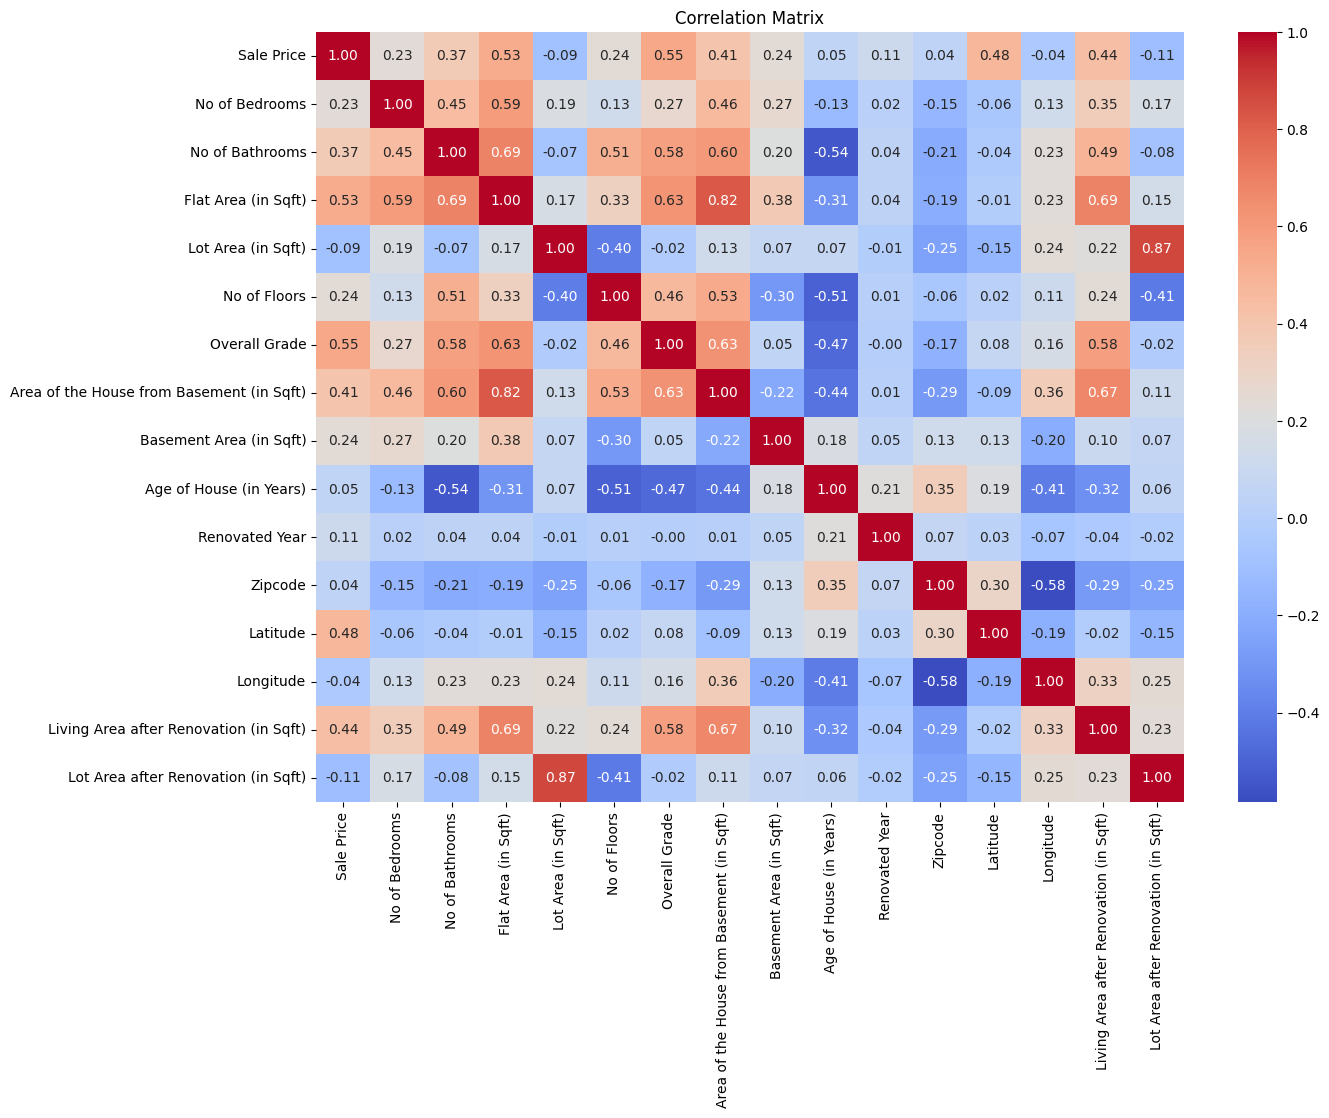

In [108]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [109]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [110]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 Date House was Sold
['14 October 2017' '14 December 2017' '15 February 2016' '14 June 2017'
 '15 January 2016' '15 April 2016' '15 March 2016' '14 May 2017'
 '14 July 2017' '14 November 2017' '14 September 2017' '14 August 2017'
 '15 May 2016']

 Waterfront View
['No' 'Yes']

 No of Times Visited
['Twice' 'Thrice' 'Four' 'Once']

 Condition of the House
['Fair' 'Excellent' 'Good' 'Okay' 'Bad']


In [111]:
df["Date House was Sold"] = pd.to_datetime(df["Date House was Sold"])

df["Sale_Year"] = df["Date House was Sold"].dt.year
df["Sale_Month"] = df["Date House was Sold"].dt.month
df["Sale_Day"] = df["Date House was Sold"].dt.day

df = df.drop("Date House was Sold", axis=1)

print(df[["Sale_Year", "Sale_Month", "Sale_Day"]].head())

   Sale_Year  Sale_Month  Sale_Day
0       2017          10        14
1       2017          12        14
2       2016           2        15
3       2017          12        14
4       2016           2        15


In [112]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Waterfront View', 'No of Times Visited', 'Condition of the House'], dtype='object')


In [113]:
df = pd.get_dummies(
    df,
    columns=["Waterfront View"],
    drop_first=True
)

print(df.head())

   Sale Price  No of Bedrooms  No of Bathrooms  Flat Area (in Sqft)  \
0    221900.0               3             1.00               1180.0   
1    538000.0               3             2.25               2570.0   
2    180000.0               2             1.00                770.0   
3    604000.0               4             3.00               1960.0   
4    510000.0               3             2.00               1680.0   

   Lot Area (in Sqft)  No of Floors No of Times Visited  \
0              5650.0           1.0               Twice   
1              7242.0           2.0               Twice   
2             10000.0           1.0               Twice   
3              5000.0           1.0               Twice   
4              8080.0           1.0               Twice   

  Condition of the House  Overall Grade  \
0                   Fair              7   
1                   Fair              7   
2                   Fair              6   
3              Excellent              7   
4  

In [114]:
visit_mapping = {
    "Once": 1,
    "Twice": 2,
    "Thrice": 3,
    "Four": 4
}

df["No of Times Visited"] = df["No of Times Visited"].map(visit_mapping)

print(df["No of Times Visited"].value_counts())

No of Times Visited
2    16166
1      201
3      184
4       68
Name: count, dtype: int64


In [115]:
condition_mapping = {
    "Bad": 1,
    "Okay": 2,
    "Fair": 3,
    "Good": 4,
    "Excellent": 5
}

df["Condition of the House"] = df["Condition of the House"].map(condition_mapping)

print(df["Condition of the House"].value_counts())

Condition of the House
3    10770
4     4364
5     1338
2      128
1       19
Name: count, dtype: int64


In [116]:
print("Remaining categorical columns:")
print(df.select_dtypes(include="object").columns)

Remaining categorical columns:
Index([], dtype='object')


#Train-Test Split


In [117]:
# Define target variable
target = "Sale Price"

# Separate features and target
X = df.drop(target, axis=1)
y = df[target]

print("Target variable:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

Target variable: Sale Price
X shape: (16619, 21)
y shape: (16619,)


In [118]:
df.head()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),...,Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Sale_Year,Sale_Month,Sale_Day,Waterfront View_Yes
0,221900.0,3,1.00,1180.0,5650.0,1.0,2,3,7,1180.0,...,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,14,False
1,538000.0,3,2.25,2570.0,7242.0,2.0,2,3,7,2170.0,...,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,14,False
2,180000.0,2,1.00,770.0,10000.0,1.0,2,3,6,770.0,...,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,15,False
3,604000.0,4,3.00,1960.0,5000.0,1.0,2,5,7,1050.0,...,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,14,False
4,510000.0,3,2.00,1680.0,8080.0,1.0,2,3,8,1680.0,...,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,15,False


In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13295, 21)
X_test shape: (3324, 21)
y_train shape: (13295,)
y_test shape: (3324,)


#Scaling Numerical Variables


In [121]:
numeric_columns = X_train.select_dtypes(include="number").columns

print("Numerical columns:")
print(numeric_columns)
print("Number of numerical columns:", len(numeric_columns))

Numerical columns:
Index(['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)', 'Sale_Year', 'Sale_Month',
       'Sale_Day'],
      dtype='object')
Number of numerical columns: 20


In [122]:
scaler = StandardScaler()

In [123]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (13295, 21)
X_test_scaled shape: (3324, 21)


In [125]:
print("Final training data shape:", X_train_scaled.shape)
print("Final testing data shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Final training data shape: (13295, 21)
Final testing data shape: (3324, 21)
Training target shape: (13295,)
Testing target shape: (3324,)


# Model Building

In [126]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [127]:
y_pred_linear = linear_model.predict(X_test_scaled)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [128]:
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(random_state=42)

In [129]:
y_pred_tree = decision_tree_model.predict(X_test_scaled)
print("Decision Tree Regression model trained successfully.")

Decision Tree Regression model trained successfully.


In [130]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_scaled, y_train)

y_pred_rf = random_forest_model.predict(X_test_scaled)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [131]:
knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN Regression model trained successfully.")

KNN Regression model trained successfully.


# Model Evaluation

In [132]:
# Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Decision Tree
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# KNN
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("Linear Regression")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

print("\nDecision Tree Regression")
print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R2 Score:", r2_tree)

print("\nRandom Forest Regression")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

print("\nKNN Regression")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

Linear Regression
MAE: 81288.55388846718
MSE: 11791311014.764996
RMSE: 108587.80325048018
R2 Score: 0.6752895570179029

Decision Tree Regression
MAE: 69427.16606498195
MSE: 9977563951.111914
RMSE: 99887.75676283812
R2 Score: 0.7252367267396413

Random Forest Regression
MAE: 48591.857907139994
MSE: 4928494926.343467
RMSE: 70203.2401413458
R2 Score: 0.8642785548812953

KNN Regression
MAE: 68038.44711191335
MSE: 9261658408.12502
RMSE: 96237.51040070092
R2 Score: 0.744951413741411


# Model Comparison

In [133]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression",
        "KNN Regression"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_knn
    ],
    "MSE": [
        mse_linear,
        mse_tree,
        mse_rf,
        mse_knn
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_knn
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_knn
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,81288.553888,1.179131e+10,108587.803250,0.675290
1,Decision Tree Regression,69427.166065,9.977564e+09,99887.756763,0.725237
2,Random Forest Regression,48591.857907,4.928495e+09,70203.240141,0.864279
3,KNN Regression,68038.447112,9.261658e+09,96237.510401,0.744951


Based on the results, Random Forest Regression performed the best among the four models. It gave the lowest MAE and RMSE and the highest R² score of 0.8643. Therefore, Random Forest Regression is the best model for predicting house prices in this dataset.